In [52]:
import numpy as np
import json
import matplotlib.pyplot as plt
import os

import cobra
import pandas as pd
import pickle

In [2]:
# Load the model
# Path relative to this notebook
model = cobra.io.read_sbml_model("../../model.xml")

In [6]:
# Load the media definitions
# Path relative to this notebook
with open("../../test/test_files/media/media_definitions.pkl", "rb") as f:
    media_definitions = pickle.load(f)

In [8]:
# Set the model's medium to the minimal glucose medium
model.medium = media_definitions["minimal_glucose"]

In [21]:
# Define the ED reaction ID
ed_rxn = model.reactions.rxn01477_c0
# Define the biomass reaction ID
biomass_rxn = "bio1_biomass"
# Define a reaction to indicate flux through the EMP
emp_rxn = model.reactions.rxn00558_c0

In [62]:
# For a range of ED use values, optimize the model and record the growth rate
ed_use = np.linspace(0, 10, 11)
results = []
for use in ed_use:
    ed_rxn.lower_bound = use
    sol = cobra.flux_analysis.pfba(model)
    results_dict = {
        "ed_use": use,
        "ed_percent": sol.fluxes[ed_rxn.id] / (sol.fluxes[ed_rxn.id] + sol.fluxes[emp_rxn.id]) * 100,
        "fluxes": sol.fluxes,
        "growth_rate": sol.fluxes[biomass_rxn],
        "cue" : 1 - (sol.fluxes["EX_cpd00011_e0"] / abs(sol.fluxes["EX_cpd00027_e0"] * 6))
    }
    results.append(results_dict)
# Convert results to a dataframe
results_df = pd.DataFrame(results)

In [63]:
results_df.head()

,ed_use,ed_percent,fluxes,growth_rate,cue
0,0.0,0.0,rxn02201_c0 5.184579e-03 rxn00351_c0 0.0...,0.805539,0.619394
1,1.0,10.0,rxn02201_c0 0.005133 rxn00351_c0 0.000...,0.797484,0.619866
2,2.0,20.0,rxn02201_c0 0.005081 rxn00351_c0 0.000...,0.789428,0.620339
3,3.0,30.0,rxn02201_c0 0.005029 rxn00351_c0 0.000...,0.781373,0.620812
4,4.0,40.0,rxn02201_c0 0.004977 rxn00351_c0 0.000...,0.773317,0.621285


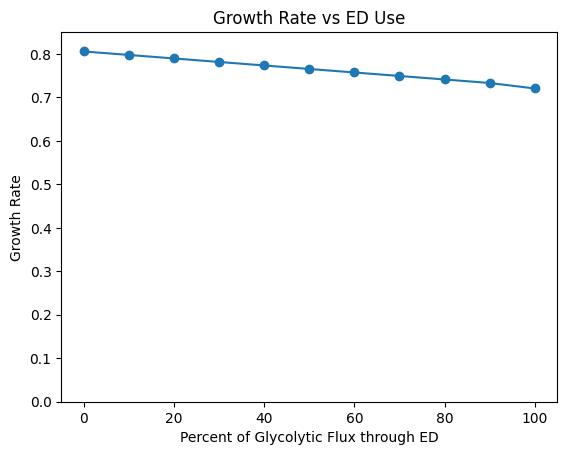

In [64]:
plt.plot(results_df["ed_percent"], results_df["growth_rate"], marker="o")
plt.xlabel("Percent of Glycolytic Flux through ED")
plt.ylabel("Growth Rate")
plt.title("Growth Rate vs ED Use")
plt.savefig("results/growth_rate_vs_ed_use.png")

# Set the y axis min to be 0
plt.ylim(0, 0.85)
plt.savefig("results/growth_rate_vs_ed_use_full_range.png")

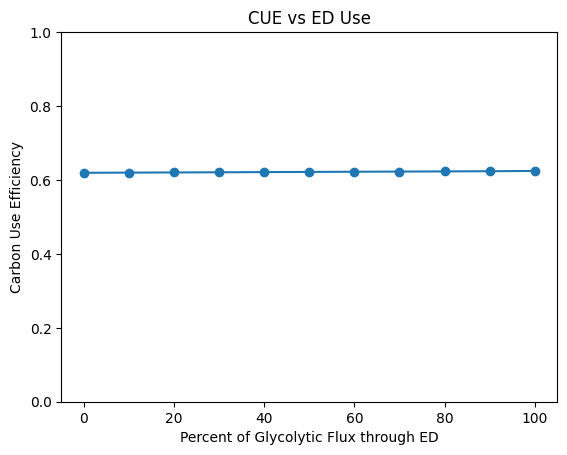

In [65]:
plt.plot(results_df["ed_percent"], results_df["cue"], marker="o")
plt.xlabel("Percent of Glycolytic Flux through ED")
plt.ylim(0, 1)
plt.ylabel("Carbon Use Efficiency")
plt.title("CUE vs ED Use")
plt.savefig("results/cue_vs_ed_use.png")

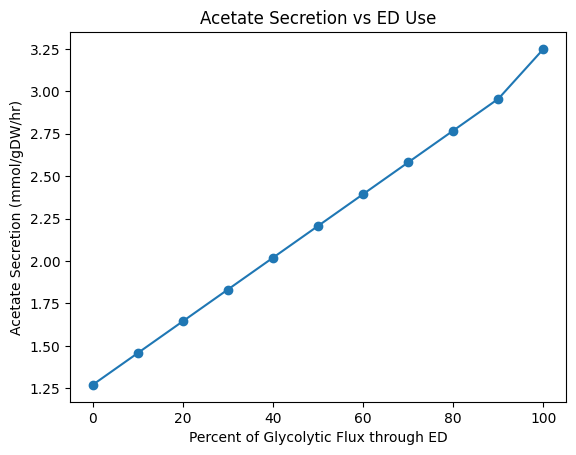

In [77]:
# Plot acetate secretion vs ed use
plt.plot(results_df["ed_percent"], results_df["fluxes"].apply(lambda x: x.get("EX_cpd00029_e0")), marker="o")
plt.xlabel("Percent of Glycolytic Flux through ED")
plt.ylabel("Acetate Secretion (mmol/gDW/hr)")
plt.title("Acetate Secretion vs ED Use")
plt.savefig("results/acetate_secretion_vs_ed_use.png")

In [ ]:
# Make a directory to save the fluxes if it doesn't exist
if not os.path.exists("results/fluxes"):
    os.makedirs("results/fluxes")

# Save all of the fluxes as json files
for i, row in results_df.iterrows():
    fluxes = row["fluxes"].to_dict()
    with open(f"results/fluxes/fluxes_ed_{row['ed_use']}.json", "w") as f:
        json.dump(fluxes, f)

# Manually make and save escher maps using the web version